In [17]:
!pip install -q insightface==0.7.3 opencv-python tqdm pandas scikit-learn matplotlib pytest
!pip uninstall -y -q onnxruntime onnxruntime-gpu
!pip install -q onnxruntime-gpu==1.22.0 nvidia-cudnn-cu12 nvidia-cublas-cu12 nvidia-cuda-runtime-cu12 nvidia-cufft-cu12 nvidia-curand-cu12 nvidia-cuda-nvrtc-cu12
# --no-deps so facenet-pytorch does not replace Colab's torch/numpy
!pip install -q --no-deps facenet-pytorch==2.6.0

In [18]:
import hashlib, json, logging, os, random, shutil, tarfile, tempfile, time, urllib.request
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Sequence, Union

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s", force=True)
log = logging.getLogger("face-id")

# ------------------------- recognition settings -------------------------
SEED = 42
THRESHOLD = 0.35       # fallback only: evaluate() tunes one threshold per model and stores it in results/metrics.json
MARGIN = 0.05          # required gap (top1 - top2), only used when USE_MARGIN is True
USE_MARGIN = False     # off by default: a gap test also rejects genuine faces when two enrolled people look alike
MIN_FACE_SIZE = 40     # px, min(bbox width, bbox height); smaller faces give unreliable embeddings
MIN_DET_SCORE = 0.5    # detector confidence below this is treated as "not a usable face"
DETECTOR_FLOOR = 0.3   # detectors run permissive; MIN_DET_SCORE is applied afterwards so weak detections are reported, not silently lost
DET_SIZE = (320, 320)  # SCRFD input size. LFW images are 250x250; use (640, 640) for large photos in identify()
DEFAULT_MODEL = "arcface"

# ------------------------- evaluation settings -------------------------
TARGET_FAR = 0.01          # threshold is chosen on validation at FAR <= 1%
N_ENROLLED = 50            # enrolled identities
MIN_IMAGES_ENROLLED = 8    # only people with >= 8 images can be enrolled (3 enroll + 2 val + >=3 test)
N_ENROLL_IMGS = 3
N_VAL_IMGS = 2
UNKNOWN_MAX_IMAGES = 2     # unknown identities = never-enrolled people with 1-2 images
NO_SCORE = -2.0            # score given to probes with no usable face (below any cosine value, so never accepted)

# ------------------------- paths (all relative) -------------------------
LFW_DIR = Path("data/lfw")
RESULTS_DIR = Path("results")
CACHE_DIR = RESULTS_DIR / "cache"
FAILURE_DIR = RESULTS_DIR / "failure_cases"
DB_PATH = Path("db/faces")      # -> db/faces.npz + db/faces.json
MODEL_DIR = Path("models")      # downloaded model weights live here, never committed

LFW_URL = "https://ndownloader.figshare.com/files/5976018"
LFW_SHA256 = "055f7d9c632d7370e6fb4afc7468d40f970c34a80d4c6f50ffec63f5a8d536c0"

# ------------------------- reproducibility -------------------------
random.seed(SEED)
np.random.seed(SEED)

# ------------------------- device detection -------------------------
import onnxruntime as ort
try:
    ort.preload_dlls()  # lets onnxruntime-gpu find the pip-installed CUDA/cuDNN libraries
except Exception as exc:
    log.warning("preload_dlls skipped: %s", exc)

# DEVICE controls the ONNX models (ArcFace/SCRFD). FaceNet uses torch and picks its own device.
# Note: CUDAExecutionProvider can be *listed* yet fail to load; the embedders re-check the real session provider.
DEVICE = "cuda" if "CUDAExecutionProvider" in ort.get_available_providers() else "cpu"
ORT_PROVIDERS = ["CUDAExecutionProvider", "CPUExecutionProvider"] if DEVICE == "cuda" else ["CPUExecutionProvider"]

log.info("onnxruntime %s | providers available: %s", ort.__version__, ort.get_available_providers())
log.info("DEVICE = %s", DEVICE)

def _json_default(o):
    """Let json.dump handle numpy scalars/arrays."""
    if isinstance(o, (np.integer, np.floating)):
        return o.item()
    if isinstance(o, np.ndarray):
        return o.tolist()
    raise TypeError(f"Not JSON serialisable: {type(o)}")


def write_json_atomic(path: Path, obj) -> None:
    """Write to a temp file, then os.replace: a crash mid-write can never leave a truncated file."""
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, default=_json_default))
    os.replace(tmp, path)


def save_npz_atomic(path: Path, **arrays) -> None:
    """Same idea for .npz files (np.savez needs the temp name to end in .npz)."""
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.stem + ".tmp.npz")
    np.savez(tmp, **arrays)
    os.replace(tmp, path)


def load_image(path: Path) -> Optional[np.ndarray]:
    """Read one image as BGR uint8, or None if unreadable.
    imdecode(fromfile) instead of imread so non-ASCII paths also work."""
    try:
        data = np.fromfile(str(path), dtype=np.uint8)
        img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    except OSError:
        img = None
    if img is None:
        log.warning("Unreadable image: %s", path)
    return img


def l2_normalize(x: np.ndarray) -> np.ndarray:
    """Unit-length rows (or vector). With unit vectors, cosine similarity is a plain dot product."""
    return x / np.maximum(np.linalg.norm(x, axis=-1, keepdims=True), 1e-12)


def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple:
    """95% Wilson interval for a rate k/n. Better than the normal approximation when the rate is near 0 or 1
    (FAR ~1%, correct-ID ~99%), which is exactly our regime."""
    if n == 0:
        return (float("nan"), float("nan"))
    p = k / n
    denom = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return (float(max(0.0, centre - half)), float(min(1.0, centre + half)))

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def download_lfw(dest: Path = LFW_DIR.parent) -> Path:
    """Download lfw.tgz from the figshare mirror, verify SHA-256, extract to <dest>/lfw/<Person>/<img>.jpg.
    (The official UMass site is down, so it is deliberately not used.)"""
    dest.mkdir(parents=True, exist_ok=True)
    tgz = dest / "lfw.tgz"
    if not tgz.exists():
        log.info("Downloading LFW (~170 MB) from figshare ...")
        part = tgz.with_name("lfw.tgz.part")  # download to a temp name so an interrupted run is never mistaken for a full file
        try:
            req = urllib.request.Request(LFW_URL, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=60) as resp, open(part, "wb") as out:
                shutil.copyfileobj(resp, out)
        except Exception as exc:
            raise RuntimeError(
                f"LFW download failed ({exc}). Download lfw.tgz manually, place it at {tgz}, and re-run; "
                f"or point LFW_DIR at an already-extracted copy."
            ) from exc
        os.replace(part, tgz)

    digest = sha256_file(tgz)
    if digest != LFW_SHA256:
        raise RuntimeError(f"SHA-256 mismatch for {tgz}: got {digest}, expected {LFW_SHA256}. "
                           f"Delete the file and download again.")
    log.info("Checksum OK. Extracting ...")
    with tarfile.open(tgz, "r:gz") as tf:
        if hasattr(tarfile, "data_filter"):
            tf.extractall(dest, filter="data")
        else:
            tf.extractall(dest)
    return dest / "lfw"


def ensure_lfw(lfw_dir: Path = LFW_DIR) -> Path:
    """Use an existing folder if present (manual copy or earlier run), otherwise download.
    lfw_dir must be named 'lfw' because the archive extracts to <parent>/lfw."""
    lfw_dir = Path(lfw_dir)
    if lfw_dir.is_dir() and any(p.is_dir() for p in lfw_dir.iterdir()):
        log.info("Using existing LFW folder: %s", lfw_dir)
        return lfw_dir
    extracted = download_lfw(lfw_dir.parent)
    if not extracted.is_dir():
        raise RuntimeError(f"Extraction finished but {extracted} does not exist.")
    return extracted


def scan_lfw(lfw_dir: Path) -> dict:
    """identity -> sorted list of image paths RELATIVE to lfw_dir ('Person/Person_0001.jpg').
    Listing folders only; no image is opened here, so nothing large is loaded into memory."""
    identities = {}
    for d in sorted(p for p in Path(lfw_dir).iterdir() if p.is_dir()):
        rels = [f"{d.name}/{f.name}" for f in sorted(d.glob("*.jpg"))]
        if rels:
            identities[d.name] = rels
    if not identities:
        raise RuntimeError(f"No <Person>/<image>.jpg files found under {lfw_dir}")
    return identities


def log_counts(identities: dict) -> None:
    """Print per-identity image counts before any split is built."""
    sizes = pd.Series({n: len(v) for n, v in identities.items()})
    buckets = pd.cut(sizes, [0, 1, 2, 5, 7, 20, 10**6],
                     labels=["1", "2", "3-5", "6-7", "8-20", ">20"]).value_counts().sort_index()
    log.info("LFW: %d identities, %d images", len(sizes), int(sizes.sum()))
    log.info("Identities by number of images:\n%s", buckets.to_string())
    log.info("Most photographed:\n%s", sizes.nlargest(5).to_string())
    log.info("Enrollable (>= %d images): %d | Unknown pool (<= %d images): %d",
             MIN_IMAGES_ENROLLED, int((sizes >= MIN_IMAGES_ENROLLED).sum()),
             UNKNOWN_MAX_IMAGES, int((sizes <= UNKNOWN_MAX_IMAGES).sum()))

LFW_DIR = ensure_lfw(LFW_DIR)      # skips the download if data/lfw already exists
identities = scan_lfw(LFW_DIR)
log_counts(identities)

2026-09-20 15:13:27,560 INFO onnxruntime 1.22.0 | providers available: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
2026-09-20 15:13:27,561 INFO DEVICE = cuda
2026-09-20 15:13:27,570 INFO Using existing LFW folder: data/lfw
2026-09-20 15:13:27,921 INFO LFW: 5749 identities, 13233 images
2026-09-20 15:13:27,922 INFO Identities by number of images:
1       4069
2        779
3-5      590
6-7       94
8-20     160
>20       57
2026-09-20 15:13:27,926 INFO Most photographed:
George_W_Bush        530
Colin_Powell         236
Tony_Blair           144
Donald_Rumsfeld      121
Gerhard_Schroeder    109
2026-09-20 15:13:27,927 INFO Enrollable (>= 8 images): 217 | Unknown pool (<= 2 images): 4848


In [19]:
!rm -rf models/insightface/models/buffalo_l

In [20]:
@dataclass
class Face:
    bbox: tuple             # (x1, y1, x2, y2) in original-image pixels
    det_score: float
    embedding: np.ndarray   # L2-normalised float32


def _area(f: Face) -> float:
    return max(f.bbox[2] - f.bbox[0], 0) * max(f.bbox[3] - f.bbox[1], 0)


def select_face(faces: list) -> tuple:
    """Pick the one face to use and say why not, if none.
    Rule: largest face with det_score >= MIN_DET_SCORE, then require min(w, h) >= MIN_FACE_SIZE.
    Returns (Face or None, status) with status in ok | no_face | low_score | too_small.
    One shared rule for enrollment, probes and the cache, so a face is never accepted in one place and rejected in another."""
    if not faces:
        return None, "no_face"
    strong = [f for f in faces if f.det_score >= MIN_DET_SCORE]
    if not strong:
        return None, "low_score"
    face = max(strong, key=_area)
    if min(face.bbox[2] - face.bbox[0], face.bbox[3] - face.bbox[1]) < MIN_FACE_SIZE:
        return None, "too_small"
    return face, "ok"


class FaceEmbedder:
    """Common interface: image (BGR uint8) -> every detected face with bbox, det_score and embedding.
    Each model does its own colour conversion, so callers always pass BGR."""
    name: str = ""
    dim: int = 0

    def detect_embed(self, img_bgr: np.ndarray) -> list:
        raise NotImplementedError

    def embed_batch(self, imgs: list) -> list:
        """Default: one image at a time. Overridden where the model can really batch (FaceNet)."""
        return [self.detect_embed(im) for im in imgs]


def _warn_if_not_on_gpu(sessions) -> None:
    """CUDA can be listed as available and still silently fall back to CPU (missing CUDA libs), so check the real session."""
    if DEVICE == "cuda" and any(s.get_providers()[0] != "CUDAExecutionProvider" for s in sessions):
        log.warning("DEVICE is cuda but an ONNX model runs on CPU. Check onnxruntime-gpu==1.22.0 and the CUDA-12 libs.")


class ArcFaceEmbedder(FaceEmbedder):
    """InsightFace buffalo_l: SCRFD detection + ArcFace (512-d). The main model.
    Only the detection and recognition modules are loaded (landmark/gender-age models are not needed and cost time).
    SCRFD's ONNX export takes one image at a time, so batching is not possible here; speed comes from the GPU."""
    name, dim = "arcface", 512

    def __init__(self):
        try:
            from insightface.app import FaceAnalysis
        except ImportError as exc:
            raise RuntimeError("insightface is not installed. Use --model sface instead, or fix the install.") from exc
        try:
            self.app = FaceAnalysis(name="buffalo_l", root=str(MODEL_DIR / "insightface"),
                                    allowed_modules=["detection", "recognition"], providers=ORT_PROVIDERS)
            self.app.prepare(ctx_id=0 if DEVICE == "cuda" else -1, det_thresh=DETECTOR_FLOOR, det_size=DET_SIZE)
        except Exception as exc:
            raise RuntimeError(f"Could not load InsightFace buffalo_l (model download or ONNX runtime problem): {exc}") from exc
        _warn_if_not_on_gpu([m.session for m in self.app.models.values()])

    def detect_embed(self, img_bgr: np.ndarray) -> list:
        return [Face(tuple(float(v) for v in f.bbox), float(f.det_score),
                     l2_normalize(f.normed_embedding.astype(np.float32)))
                for f in self.app.get(img_bgr)]


class FaceNetEmbedder(FaceEmbedder):
    """facenet-pytorch: MTCNN detection + InceptionResnetV1 (VGGFace2, 512-d). Comparison model only.
    Batched: MTCNN detects on a stack of same-size images and all crops go through the network in one forward pass."""
    name, dim = "facenet", 512

    def __init__(self):
        try:
            os.environ.setdefault("TORCH_HOME", str(MODEL_DIR / "torch"))  # keep weights inside the project folder
            import torch
            from facenet_pytorch import MTCNN, InceptionResnetV1
            self.torch = torch
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            self.mtcnn = MTCNN(keep_all=True, device=self.device)
            self.resnet = InceptionResnetV1(pretrained="vggface2").eval().to(self.device)
        except Exception as exc:
            raise RuntimeError(f"Could not load facenet-pytorch (install with --no-deps, or the weight download failed): {exc}") from exc

    def detect_embed(self, img_bgr: np.ndarray) -> list:
        return self.embed_batch([img_bgr])[0]

    def embed_batch(self, imgs: list) -> list:
        results = [[] for _ in imgs]
        groups = {}                      # MTCNN batch mode needs equal-size images, so group by shape
        for i, im in enumerate(imgs):
            groups.setdefault(im.shape, []).append(i)
        for idxs in groups.values():
            self._run_group(imgs, idxs, results)
        return results

    def _run_group(self, imgs: list, idxs: list, results: list) -> None:
        rgb = np.stack([cv2.cvtColor(imgs[i], cv2.COLOR_BGR2RGB) for i in idxs])  # facenet-pytorch expects RGB
        boxes, probs = self.mtcnn.detect(rgb)
        height, width = rgb.shape[1:3]
        crops, owners = [], []
        for k, i in enumerate(idxs):
            if boxes[k] is None:
                continue
            for box, p in zip(boxes[k], probs[k]):
                x1, y1 = max(int(round(box[0])), 0), max(int(round(box[1])), 0)
                x2, y2 = min(int(round(box[2])), width), min(int(round(box[3])), height)
                if x2 - x1 < 2 or y2 - y1 < 2:
                    continue
                crops.append(cv2.resize(rgb[k][y1:y2, x1:x2], (160, 160), interpolation=cv2.INTER_AREA))
                owners.append((i, (float(box[0]), float(box[1]), float(box[2]), float(box[3])), float(p)))
        if not crops:
            return
        x = self.torch.from_numpy(np.stack(crops)).permute(0, 3, 1, 2).float().to(self.device)
        x = (x - 127.5) / 128.0          # the standardisation InceptionResnetV1 was trained with
        with self.torch.inference_mode():
            emb = l2_normalize(self.resnet(x).cpu().numpy().astype(np.float32))
        for (i, bbox, p), e in zip(owners, emb):
            results[i].append(Face(bbox, p, e))


YUNET_URL = "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
SFACE_URL = "https://github.com/opencv/opencv_zoo/raw/main/models/face_recognition_sface/face_recognition_sface_2021dec.onnx"


def download_model(url: str, dest: Path) -> Path:
    """Download a model file once, with a clear error if it fails."""
    if dest.exists() and dest.stat().st_size > 100_000:
        return dest
    dest.parent.mkdir(parents=True, exist_ok=True)
    part = dest.with_name(dest.name + ".part")
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as resp, open(part, "wb") as out:
            shutil.copyfileobj(resp, out)
    except Exception as exc:
        raise RuntimeError(f"Could not download {url} ({exc}). Check the network, or place the file at {dest}.") from exc
    if part.stat().st_size < 100_000:   # the zoo stores models in Git LFS; a failed redirect returns a ~130-byte pointer file
        part.unlink()
        raise RuntimeError(f"Download of {url} returned a tiny file (a Git-LFS pointer, not the model). Place the file at {dest} manually.")
    os.replace(part, dest)
    return dest


import threading   # add this near your other imports at the top (Cell 2), if not already there

class SFaceEmbedder(FaceEmbedder):
    """OpenCV Zoo: YuNet detector + SFace embedder (128-d). Lightweight comparison model and the fallback if InsightFace won't install.
    The pip OpenCV wheel is CPU-only, so this model runs on CPU even on a GPU runtime (it is small, so this is fine).
    cv2's DNN backend is not thread-safe, so calls are serialized with a lock."""
    name, dim = "sface", 128

    def __init__(self):
        if not (hasattr(cv2, "FaceDetectorYN") and hasattr(cv2, "FaceRecognizerSF")):
            raise RuntimeError(f"OpenCV {cv2.__version__} has no FaceDetectorYN/FaceRecognizerSF; OpenCV >= 4.8 is required.")
        det = download_model(YUNET_URL, MODEL_DIR / "opencv_zoo" / "face_detection_yunet_2023mar.onnx")
        rec = download_model(SFACE_URL, MODEL_DIR / "opencv_zoo" / "face_recognition_sface_2021dec.onnx")
        self.detector = cv2.FaceDetectorYN.create(str(det), "", (320, 320), DETECTOR_FLOOR, 0.3, 5000)
        self.recognizer = cv2.FaceRecognizerSF.create(str(rec), "")
        self._lock = threading.Lock()

    def detect_embed(self, img_bgr: np.ndarray) -> list:
        with self._lock:
            h, w = img_bgr.shape[:2]
            self.detector.setInputSize((w, h))
            _, dets = self.detector.detect(img_bgr)
            if dets is None:
                return []
            faces = []
            for row in dets:                                   # row = x, y, w, h, 5 landmarks (10 values), score
                feat = self.recognizer.feature(self.recognizer.alignCrop(img_bgr, row)).flatten().astype(np.float32)
                x, y, bw, bh = (float(v) for v in row[:4])
                faces.append(Face((x, y, x + bw, y + bh), float(row[-1]), l2_normalize(feat)))
            return faces


EMBEDDERS = {"arcface": ArcFaceEmbedder, "facenet": FaceNetEmbedder, "sface": SFaceEmbedder}
_instances = {}


def get_embedder(name: str, allow_fallback: bool = True) -> FaceEmbedder:
    """Load a model once and reuse it. If ArcFace cannot load and fallback is allowed, use SFace so the system still runs.
    (The database records which model made the embeddings, so a fallback can never silently mix models.)"""
    if name not in EMBEDDERS:
        raise ValueError(f"Unknown model '{name}'. Choose from {sorted(EMBEDDERS)}.")
    if name not in _instances:
        try:
            _instances[name] = EMBEDDERS[name]()
        except RuntimeError as exc:
            if name == "arcface" and allow_fallback:
                log.error("%s\nFalling back to SFace.", exc)
                return get_embedder("sface", allow_fallback=False)
            raise
    return _instances[name]


In [21]:
p_same = next(v for v in identities.values() if len(v) >= 2)
p_other = next(v for v in identities.values() if v is not p_same)
pair = {"same person": (p_same[0], p_same[1]), "different people": (p_same[0], p_other[0])}

for model in EMBEDDERS:
    try:
        emb = get_embedder(model, allow_fallback=False)
    except RuntimeError as exc:
        log.error("%s unavailable: %s", model, exc)
        continue
    t0 = time.time()
    got = {}
    for label, (a, b) in pair.items():
        fa, sa = select_face(emb.detect_embed(load_image(LFW_DIR / a)))
        fb, sb = select_face(emb.detect_embed(load_image(LFW_DIR / b)))
        got[label] = float(fa.embedding @ fb.embedding) if fa and fb else None
    log.info("%s | dim=%d | status=%s | cosine same=%s, different=%s | %.1fs",
             model, emb.dim, sa, got["same person"], got["different people"], time.time() - t0)

download_path: models/insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:04<00:00, 64726.23KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
model ignore: models/insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvid

2026-09-20 15:13:41,577 INFO arcface | dim=512 | status=ok | cosine same=0.7993876338005066, different=-0.021878063678741455 | 0.5s
2026-09-20 15:13:43,046 INFO facenet | dim=512 | status=ok | cosine same=0.8611710071563721, different=0.04066658765077591 | 0.4s
2026-09-20 15:13:43,462 INFO sface | dim=128 | status=ok | cosine same=0.8187339305877686, different=0.09087461233139038 | 0.3s


In [22]:
class ModelMismatchError(RuntimeError):
    """Raised when embeddings from one model would be mixed with another model's database."""


@dataclass
class Match:
    identity: Optional[str]   # None = "unknown" (best score below threshold, or empty database)
    score: float              # best cosine over enrolled identities (-1.0 if the database is empty)
    ranked: list              # [(identity, score), ...] best first, length <= top_k


class FaceDB:
    """Enrolled identities: one row per embedding, all from ONE model.
    Identity score = max cosine over that identity's rows."""
    VERSION = 1

    def __init__(self, model: str, dim: int):
        self.model, self.dim = model, dim
        self._emb = np.zeros((0, dim), dtype=np.float32)
        self._labels: list = []
        self._sources: list = []

    def __len__(self) -> int:
        return len(self._labels)

    def identities(self) -> dict:
        """identity -> number of enrolled embeddings."""
        counts = {}
        for name in self._labels:
            counts[name] = counts.get(name, 0) + 1
        return counts

    def add(self, identity: str, embeddings: np.ndarray, model: str, sources: Optional[list] = None) -> int:
        """Add embeddings for an identity (creates it, or adds more rows to an existing one).
        Rows whose source image is already enrolled for this identity are skipped. Returns rows added."""
        if model != self.model:
            raise ModelMismatchError(f"Database was built with '{self.model}', got embeddings from '{model}'.")
        emb = np.atleast_2d(np.asarray(embeddings, dtype=np.float32))
        if emb.shape[1] != self.dim:
            raise ModelMismatchError(f"Embedding dim {emb.shape[1]} != database dim {self.dim}.")
        if not np.isfinite(emb).all():
            raise ValueError("Embeddings contain NaN or inf.")
        sources = list(sources) if sources is not None else [""] * len(emb)
        if len(sources) != len(emb):
            raise ValueError("sources must have one entry per embedding.")
        have = {s for n, s in zip(self._labels, self._sources) if n == identity and s}
        keep = [i for i, s in enumerate(sources) if not (s and s in have)]
        if not keep:
            return 0
        self._emb = np.vstack([self._emb, l2_normalize(emb[keep])])
        self._labels += [identity] * len(keep)
        self._sources += [sources[i] for i in keep]
        return len(keep)

    def remove(self, identity: str) -> int:
        """Delete every row of an identity. Returns rows removed; KeyError if the identity is not enrolled."""
        mask = np.array([n == identity for n in self._labels], dtype=bool)
        if not mask.any():
            raise KeyError(f"Identity not enrolled: {identity}")
        self._emb = self._emb[~mask]
        self._labels = [n for n, m in zip(self._labels, mask) if not m]
        self._sources = [s for s, m in zip(self._sources, mask) if not m]
        return int(mask.sum())

    def match(self, probe: np.ndarray, threshold: float, top_k: int = 5) -> Match:
        """Best identity for a unit-length probe embedding; identity=None if the best score < threshold."""
        if len(self) == 0:
            return Match(None, -1.0, [])
        sims = self._emb @ l2_normalize(np.asarray(probe, dtype=np.float32))
        names, inv = np.unique(np.array(self._labels), return_inverse=True)
        best = np.full(len(names), -np.inf, dtype=np.float32)
        np.maximum.at(best, inv, sims)
        order = np.argsort(-best)[:top_k]
        ranked = [(str(names[i]), float(best[i])) for i in order]
        top_name, top_score = ranked[0]
        return Match(top_name if top_score >= threshold else None, top_score, ranked)

    def save(self, path: Path) -> None:
        meta = {"version": self.VERSION, "model": self.model, "dim": self.dim}
        save_npz_atomic(Path(path), embeddings=self._emb,
                        labels=np.array(self._labels, dtype=str),
                        sources=np.array(self._sources, dtype=str),
                        meta=np.array(json.dumps(meta)))

    @classmethod
    def load(cls, path: Path, expected_model: Optional[str] = None) -> "FaceDB":
        with np.load(Path(path), allow_pickle=False) as z:
            meta = json.loads(str(z["meta"]))
            if meta["version"] != cls.VERSION:
                raise RuntimeError(f"Unsupported database version {meta['version']} in {path}.")
            if expected_model is not None and meta["model"] != expected_model:
                raise ModelMismatchError(
                    f"{path} was built with '{meta['model']}', but '{expected_model}' was requested. "
                    f"Re-enroll with '{expected_model}' or load with the matching model.")
            db = cls(meta["model"], meta["dim"])
            emb = z["embeddings"].astype(np.float32)
            labels, sources = [str(x) for x in z["labels"]], [str(x) for x in z["sources"]]
        if emb.shape != (len(labels), db.dim) or len(sources) != len(labels):
            raise RuntimeError(f"{path} is inconsistent (embeddings/labels/sources sizes differ).")
        db._emb, db._labels, db._sources = emb, labels, sources
        return db

In [23]:
def embed_face(embedder, rel):
    img = load_image(LFW_DIR / rel)
    face, status = select_face(embedder.detect_embed(img)) if img is not None else (None, "unreadable")
    assert face is not None, f"{rel}: {status}"
    return face


emb = get_embedder("arcface", allow_fallback=False)
TEST_THR = 0.4        # placeholder just for this test; real thresholds are calibrated in a later step
db = FaceDB(emb.name, emb.dim)

people = [(n, v) for n, v in identities.items() if len(v) >= 2][:3]
stranger_name, stranger_imgs = next((n, v) for n, v in identities.items() if len(v) == 1)

for name, rels in people:
    db.add(name, embed_face(emb, rels[0]).embedding[None], model=emb.name, sources=[rels[0]])
log.info("Enrolled: %s", db.identities())

for name, rels in people:                                   # expect: correct identity, score above threshold
    m = db.match(embed_face(emb, rels[1]).embedding, TEST_THR)
    log.info("probe %-22s -> %s (%.3f) %s", name, m.identity, m.score, "OK" if m.identity == name else "WRONG")

m = db.match(embed_face(emb, stranger_imgs[0]).embedding, TEST_THR)   # expect: None (unknown)
log.info("probe %-22s -> %s (%.3f) %s", stranger_name, m.identity, m.score, "OK" if m.identity is None else "WRONG")

path = LFW_DIR.parent / "smoke_db.npz"                      # save/load round trip
db.save(path)
db2 = FaceDB.load(path, expected_model="arcface")
assert db2.identities() == db.identities() and np.allclose(db2._emb, db._emb)
log.info("Save/load round trip OK")

for label, fn in [("load with wrong model", lambda: FaceDB.load(path, expected_model="sface")),
                  ("add wrong-model embeddings", lambda: db.add("X", np.zeros((1, 128), np.float32), model="sface"))]:
    try:
        fn()
        log.error("%s: NOT refused (bug)", label)
    except ModelMismatchError as exc:
        log.info("%s: refused as expected", label)

log.info("Removed %d row(s) for %s; left: %s", db.remove(people[0][0]), people[0][0], db.identities())

2026-09-20 15:13:43,695 INFO Enrolled: {'Aaron_Peirsol': 1, 'Aaron_Sorkin': 1, 'Abdel_Nasser_Assidi': 1}
2026-09-20 15:13:43,722 INFO probe Aaron_Peirsol          -> Aaron_Peirsol (0.799) OK
2026-09-20 15:13:43,751 INFO probe Aaron_Sorkin           -> Aaron_Sorkin (0.672) OK
2026-09-20 15:13:43,814 INFO probe Abdel_Nasser_Assidi    -> Abdel_Nasser_Assidi (0.844) OK
2026-09-20 15:13:43,844 INFO probe AJ_Cook                -> None (0.038) OK
2026-09-20 15:13:43,857 INFO Save/load round trip OK
2026-09-20 15:13:43,859 INFO load with wrong model: refused as expected
2026-09-20 15:13:43,860 INFO add wrong-model embeddings: refused as expected
2026-09-20 15:13:43,861 INFO Removed 1 row(s) for Aaron_Peirsol; left: {'Aaron_Sorkin': 1, 'Abdel_Nasser_Assidi': 1}


In [24]:
N_ENROLLED = 50
ENROLL_PER_ID = 3
VAL_PER_ID = 2                 # spec: 1-2 validation images per enrolled person
MAX_TEST_PER_ID = 10           # None = "the rest". Cap stops one heavily photographed person dominating the rates.
TARGET_FAR = 0.01
SPLIT_SEED = 0
RESULTS_DIR = Path("results")
THRESHOLD_METHOD = "highest threshold-free rule: lowest threshold with FAR <= 1% on the validation unknowns"


def make_split(identities: dict, seed: int = SPLIT_SEED) -> dict:
    """Split by IDENTITY first, then by image. fold 0 = validation (picks the threshold), fold 1 = test (reported once)."""
    assert MIN_IMAGES_ENROLLED >= ENROLL_PER_ID + VAL_PER_ID + 1, "Need at least one test image per enrolled person."
    rng = np.random.default_rng(seed)
    pool = sorted(n for n, v in identities.items() if len(v) >= MIN_IMAGES_ENROLLED)
    enrolled_ids = sorted(rng.choice(pool, size=min(N_ENROLLED, len(pool)), replace=False).tolist())
    unknown_ids = sorted(n for n, v in identities.items() if len(v) <= UNKNOWN_MAX_IMAGES)
    assert not set(enrolled_ids) & set(unknown_ids), "Enrolled and unknown pools overlap."

    gallery, probes_known = {}, []
    for n in enrolled_ids:
        rels = list(identities[n])
        rng.shuffle(rels)
        gallery[n] = rels[:ENROLL_PER_ID]
        val = rels[ENROLL_PER_ID:ENROLL_PER_ID + VAL_PER_ID]
        test = rels[ENROLL_PER_ID + VAL_PER_ID:]
        if MAX_TEST_PER_ID is not None:
            test = test[:MAX_TEST_PER_ID]
        probes_known += [(n, r, 0) for r in val] + [(n, r, 1) for r in test]

    rng.shuffle(unknown_ids)
    half = len(unknown_ids) // 2       # split by identity: no unknown person appears in both halves
    probes_unknown = [(n, identities[n][0], 0 if k < half else 1) for k, n in enumerate(unknown_ids)]

    # image-level guarantee that no enrollment image is ever used as a probe
    enroll_imgs = {r for rels in gallery.values() for r in rels}
    for _, r, _ in probes_known + probes_unknown:
        assert r not in enroll_imgs, f"Enrollment image used as a probe: {r}"
    val_imgs = {r for _, r, f in probes_known if f == 0}
    test_imgs = {r for _, r, f in probes_known if f == 1}
    assert not val_imgs & test_imgs, "Validation and test images overlap."
    return {"gallery": gallery, "probes_known": probes_known, "probes_unknown": probes_unknown}

def score_probes(embedder, cache: dict, split: dict):
    """Enroll the gallery, then match every usable probe once against it (threshold=-1 so the top identity is always returned).
    Sweeping thresholds afterwards needs no re-matching."""
    db = FaceDB(embedder.name, embedder.dim)
    for n, rels in split["gallery"].items():
        good = [r for r in rels if cache[r][1] is not None]
        if good:
            db.add(n, np.stack([cache[r][1] for r in good]), model=embedder.name, sources=good)
    enrolled = set(db.identities())
    rows = {"known": [], "unknown": []}
    fta = {"known": 0, "unknown": 0}          # failure to acquire: no usable face in the probe image
    for kind, probes in (("known", split["probes_known"]), ("unknown", split["probes_unknown"])):
        for name, rel, fold in probes:
            if kind == "known" and name not in enrolled:
                continue                        # none of this person's enrollment images gave a usable face
            emb = cache[rel][1]
            if emb is None:
                fta[kind] += 1
                continue
            m = db.match(emb, threshold=-1.0, top_k=1)
            rows[kind].append((name, m.identity, m.score, fold, rel))
    return db, rows, fta


def to_arrays(rows: list, known: bool) -> dict:
    a = {"score": np.array([r[2] for r in rows], dtype=np.float64),
         "fold": np.array([r[3] for r in rows], dtype=int),
         "true": np.array([r[0] for r in rows], dtype=str),
         "pred": np.array([r[1] for r in rows], dtype=str),
         "rel": np.array([r[4] for r in rows], dtype=str)}
    if known:
        a["correct"] = a["true"] == a["pred"]
    return a


def subset(d: dict, fold: int) -> dict:
    m = d["fold"] == fold
    return {k: v[m] for k, v in d.items()}


def pick_threshold(unknown_scores: np.ndarray, far: float) -> float:
    """Lowest threshold at which at most `far` of the unknown probes are accepted (accept = score >= threshold)."""
    s = np.sort(np.asarray(unknown_scores, dtype=np.float64))[::-1]
    k = int(np.floor(far * len(s)))
    return -1.0 if k >= len(s) else float(np.nextafter(s[k], np.inf))


def _rate(k: int, n: int) -> dict:
    lo, hi = wilson_ci(int(k), int(n))
    return {"k": int(k), "n": int(n), "rate": (k / n) if n else float("nan"), "ci95": [lo, hi]}


def metrics(thr: float, kn: dict, un: dict) -> dict:
    """Known probe -> correct ID, wrong ID (accepted as someone else) or false reject (score < thr).
    FRR = wrong ID + false reject (known probes not correctly identified). FAR is measured on unknown probes only."""
    n_k, n_u = len(kn["score"]), len(un["score"])
    accepted = kn["score"] >= thr
    correct = int((accepted & kn["correct"]).sum())
    wrong = int((accepted & ~kn["correct"]).sum())
    acc_u = int((un["score"] >= thr).sum())
    return {"threshold": float(thr),
            "correct_id": _rate(correct, n_k),
            "wrong_id": _rate(wrong, n_k),
            "false_reject": _rate(n_k - correct - wrong, n_k),
            "frr": _rate(n_k - correct, n_k),
            "far": _rate(acc_u, n_u),
            "unknown_rejection": _rate(n_u - acc_u, n_u)}

In [25]:
# NOTE: build_cache / load_cache were missing from the original notebook —
# evaluate_model() calls build_cache() below, and the debug cell further
# down calls load_cache(). Both are added here, right before their first use.
# --------------------------------------------------------------------------

def build_cache(embedder, rels: list, cache_dir: Path = CACHE_DIR) -> dict:
    """rel path -> (status, embedding_or_None). Persisted to disk per model so reruns don't
    recompute embeddings for images already processed."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"{embedder.name}.npz"
    cache = {}
    if cache_path.exists():
        with np.load(cache_path, allow_pickle=False) as z:
            for r, st, e, has_e in zip(z["rels"], z["status"], z["embeddings"], z["has_emb"]):
                cache[str(r)] = (str(st), e.astype(np.float32) if has_e else None)

    missing = [r for r in rels if r not in cache]
    if missing:
        def _one(rel):
            img = load_image(LFW_DIR / rel)
            if img is None:
                return rel, "unreadable", None
            face, status = select_face(embedder.detect_embed(img))
            return rel, status, (face.embedding if face is not None else None)

        with ThreadPoolExecutor(max_workers=8) as ex:
            for rel, status, emb in tqdm(ex.map(_one, missing), total=len(missing),
                                          desc=f"embedding ({embedder.name})"):
                cache[rel] = (status, emb)

        all_rels = list(cache.keys())
        dim = embedder.dim
        embs = np.zeros((len(all_rels), dim), dtype=np.float32)
        has_emb = np.zeros(len(all_rels), dtype=bool)
        status_arr = np.empty(len(all_rels), dtype=object)
        for i, r in enumerate(all_rels):
            st, e = cache[r]
            status_arr[i] = st
            if e is not None:
                embs[i] = e
                has_emb[i] = True
        save_npz_atomic(cache_path, rels=np.array(all_rels, dtype=str),
                         status=status_arr.astype(str), embeddings=embs, has_emb=has_emb)

    return {r: cache[r] for r in rels}


def load_cache(name: str) -> dict:
    """Read a model's cache from disk without recomputing anything. Raises if it hasn't been built yet."""
    cache_path = CACHE_DIR / f"{name}.npz"
    if not cache_path.exists():
        raise RuntimeError(f"No cache for '{name}' at {cache_path}; run build_cache() for it first.")
    with np.load(cache_path, allow_pickle=False) as z:
        return {str(r): (str(st), e.astype(np.float32) if he else None)
                for r, st, e, he in zip(z["rels"], z["status"], z["embeddings"], z["has_emb"])}


def evaluate_model(name: str, split: dict, need: list):
    emb = get_embedder(name, allow_fallback=False)
    cache = build_cache(emb, need)
    db, rows, fta = score_probes(emb, cache, split)
    kn, un = to_arrays(rows["known"], True), to_arrays(rows["unknown"], False)
    thr = pick_threshold(subset(un, 0)["score"], TARGET_FAR)      # validation only
    kn_t, un_t = subset(kn, 1), subset(un, 1)                     # test: touched once, after the threshold is fixed
    no_face = {}
    for r in need:
        if cache[r][0] != "ok":
            no_face[cache[r][0]] = no_face.get(cache[r][0], 0) + 1
    result = {"model": name, "dim": emb.dim, "enrolled_identities": len(db.identities()), "enrolled_rows": len(db),
              "images_without_usable_face": no_face, "probes_without_usable_face": fta,
              "validation": metrics(thr, subset(kn, 0), subset(un, 0)),
              "test": metrics(thr, kn_t, un_t),
              "closed_set_top1_test": metrics(-1.0, kn_t, un_t)["correct_id"]}
    return result, kn, un


# --------------------------------------------------------------------------
# NOTE: the original notebook had a SECOND, stale block here that called
# evaluate_model() without unpacking its (result, kn, un) tuple, then passed
# that tuple into log_report(), which expects a dict — that's the exact
# "TypeError: tuple indices must be integers or slices, not str" you hit.
# That block (results = {}; log_report(...); the first summary print) has
# been removed. The correct evaluation run is the block near the bottom of
# this file (the one that does `results[model], kn, un = evaluate_model(...)`).
# --------------------------------------------------------------------------

In [26]:
split = make_split(identities)
need = sorted({r for rels in split["gallery"].values() for r in rels}
              | {r for _, r, _ in split["probes_known"]} | {r for _, r, _ in split["probes_unknown"]})
log.info("Split: %d enrolled people, %d known probes, %d unknown probes, %d images to embed per model",
         len(split["gallery"]), len(split["probes_known"]), len(split["probes_unknown"]), len(need))

name = "arcface"
emb = get_embedder(name, allow_fallback=False)
_ = build_cache(emb, need)                      # build the cache first
db, rows, fta = score_probes(emb, load_cache(name), split)
thr_result, _, _ = evaluate_model(name, split, need)   # reuses the cache just built, doesn't redo embedding
thr = thr_result["test"]["threshold"]
un = rows["unknown"]                       # (person, matched_identity, score, fold, rel)
for fold in (0, 1):
    n = sum(1 for r in un if r[3] == fold)
    k = sum(1 for r in un if r[3] == fold and r[2] >= thr)
    print(f"fold {fold}: {k}/{n} unknown probes accepted at thr {thr:.3f}")
worst = sorted((r for r in un if r[3] == 1 and r[2] >= thr), key=lambda r: -r[2])[:15]
for person, matched, score, _, _ in worst:
    print(f"{score:.3f}  {person:30s} -> {matched}")

2026-09-20 15:13:43,980 INFO Split: 50 enrolled people, 445 known probes, 4848 unknown probes, 5443 images to embed per model


fold 0: 24/2424 unknown probes accepted at thr 0.254
fold 1: 41/2424 unknown probes accepted at thr 0.254
0.683  Barbara_Boxer                  -> Gray_Davis
0.524  Antanas_Valionis               -> Colin_Powell
0.508  Sherry_Fisher                  -> Al_Gore
0.421  Sylvia_Plachy                  -> Adrien_Brody
0.333  Princess_Masako                -> Heizo_Takenaka
0.327  Chung_Mong-hun                 -> Jeong_Se-hyun
0.320  Ren_Qingjin                    -> Tang_Jiaxuan
0.319  Amanda_Beard                   -> Maria_Shriver
0.302  Zhang_Wenkang                  -> Wen_Jiabao
0.297  Olivier_Rochus                 -> Mike_Weir
0.295  Bill_King                      -> James_Kelly
0.286  Mehdi_Baala                    -> Richard_Virenque
0.284  Cha_Yung-gu                    -> Jeong_Se-hyun
0.283  Wen_Ho_Lee                     -> Atal_Bihari_Vajpayee
0.280  Jennifer_Love_Hewitt           -> Naomi_Watts


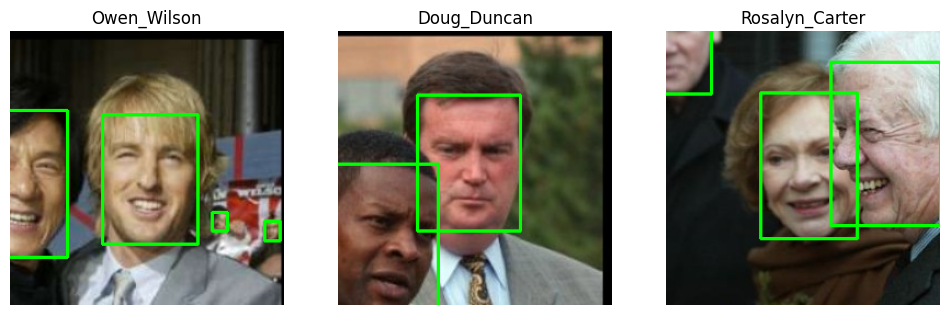

In [27]:
import matplotlib.pyplot as plt
emb = get_embedder("arcface", allow_fallback=False)
rels = ["Owen_Wilson/Owen_Wilson_0001.jpg", "Doug_Duncan/Doug_Duncan_0001.jpg", "Rosalyn_Carter/Rosalyn_Carter_0001.jpg"]
fig, axes = plt.subplots(1, len(rels), figsize=(12, 4))
for ax, r in zip(axes, rels):
    img = load_image(LFW_DIR / r)
    if img is None:
        ax.set_title(f"{r}: unreadable"); ax.axis("off"); continue
    for f in emb.detect_embed(img):
        x1, y1, x2, y2 = map(int, f.bbox)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    ax.imshow(img[:, :, ::-1]); ax.set_title(r.split("/")[0]); ax.axis("off")
plt.show()

In [28]:
split = make_split(identities)
need = sorted({r for rels in split["gallery"].values() for r in rels}
              | {r for _, r, _ in split["probes_known"]} | {r for _, r, _ in split["probes_unknown"]})
log.info("Split: %d enrolled, %d known probes, %d unknown probes, %d images per model",
         len(split["gallery"]), len(split["probes_known"]), len(split["probes_unknown"]), len(need))

results, scores = {}, {}
for model in EMBEDDERS:
    try:
        results[model], kn, un = evaluate_model(model, split, need)
        scores[model] = (kn, un)
    except RuntimeError as exc:
        log.error("%s skipped: %s", model, exc)

write_json_atomic(RESULTS_DIR / "metrics.json", {
    "threshold_method": "lowest threshold with FAR <= %.0f%% on validation unknowns; then evaluated once on test" % (TARGET_FAR * 100),
    "split": {"seed": SPLIT_SEED, "enrolled": len(split["gallery"]), "enroll_per_id": ENROLL_PER_ID,
              "val_per_id": VAL_PER_ID, "max_test_per_id": MAX_TEST_PER_ID,
              "known_probes": len(split["probes_known"]), "unknown_probes": len(split["probes_unknown"])},
    "models": results})

print(pd.DataFrame([{
    "model": m, "threshold": round(r["test"]["threshold"], 3),
    "top1_%": round(r["closed_set_top1_test"]["rate"] * 100, 2),
    "correct_id_%": round(r["test"]["correct_id"]["rate"] * 100, 2),
    "FRR_%": round(r["test"]["frr"]["rate"] * 100, 2),
    "FAR_%": round(r["test"]["far"]["rate"] * 100, 2),
    "unk_reject_%": round(r["test"]["unknown_rejection"]["rate"] * 100, 2),
    "no_face_imgs": sum(r["images_without_usable_face"].values()),
} for m, r in results.items()]).to_string(index=False))

2026-09-20 15:13:46,010 INFO Split: 50 enrolled, 445 known probes, 4848 unknown probes, 5443 images per model


embedding (sface):   0%|          | 0/5443 [00:00<?, ?it/s]

  model  threshold  top1_%  correct_id_%  FRR_%  FAR_%  unk_reject_%  no_face_imgs
arcface      0.254   97.97         97.97   2.03   1.69         98.31             0
facenet      0.659   97.39         91.88   8.12   1.57         98.43             0
  sface      0.424   99.42         99.42   0.58   0.70         99.30             0


In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

FAIL_DIR = RESULTS_DIR / "failure_cases"
FAIL_TOTAL = 10


def plot_scores(name: str, thr: float, kn: dict, un: dict) -> None:
    """Left: FAR and FRR vs threshold with the chosen one marked. Right: genuine vs impostor scores.
    Drawn from the test fold for display only; thr was fixed on validation and is not re-chosen here."""
    lo = min(kn["score"].min(), un["score"].min())
    hi = max(kn["score"].max(), un["score"].max())
    ts = np.linspace(lo, hi, 400)
    far = (un["score"][None, :] >= ts[:, None]).mean(axis=1)
    frr = 1 - ((kn["score"][None, :] >= ts[:, None]) & kn["correct"][None, :]).mean(axis=1)  # FRR counts wrong IDs, as in metrics()
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
    a1.plot(ts, far, label="FAR")
    a1.plot(ts, frr, label="FRR")
    a1.axvline(thr, color="k", ls="--", label=f"chosen threshold {thr:.3f}")
    a1.set(xlabel="threshold", ylabel="rate", title=f"{name}: FAR / FRR vs threshold (test)")
    a1.legend()
    a2.hist(kn["score"][kn["correct"]], bins=40, alpha=0.6, density=True, label="genuine (correctly matched known)")
    a2.hist(un["score"], bins=40, alpha=0.6, density=True, label="impostor (unknown probes)")
    a2.axvline(thr, color="k", ls="--")
    a2.set(xlabel="best cosine score", ylabel="density (each group normalised)", title=f"{name}: score distributions")
    a2.legend()
    fig.tight_layout()
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(RESULTS_DIR / f"{name}_scores.png", dpi=120)
    plt.show()


def plot_confusion(name: str, thr: float, kn: dict, un: dict, enrolled: list) -> None:
    """Row-normalised confusion matrix over enrolled people plus 'unknown' (true unknowns, and anything rejected by thr)."""
    labels = list(enrolled) + ["unknown"]
    y_true = np.concatenate([kn["true"], np.full(len(un["score"]), "unknown")])
    scores = np.concatenate([kn["score"], un["score"]])
    y_pred = np.where(scores >= thr, np.concatenate([kn["pred"], un["pred"]]), "unknown")
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    frac = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(frac, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=5)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=5)
    ax.set(xlabel="predicted", ylabel="true", title=f"{name}: confusion matrix (test, row-normalised)")
    fig.colorbar(im, ax=ax, fraction=0.04)
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / f"{name}_confusion.png", dpi=150)
    plt.show()


def save_failure_cases(name: str, thr: float, kn: dict, un: dict) -> None:
    """Save FAIL_TOTAL annotated test images, rotating through false accepts, false rejects and misidentifications
    (worst first within each kind), so all three kinds appear when they exist."""
    emb = get_embedder(name, allow_fallback=False)
    acc = kn["score"] >= thr

    def pack(d, idx):
        return [(d["true"][i], d["pred"][i], float(d["score"][i]), d["rel"][i]) for i in idx]

    groups = {
        "false_accept": pack(un, [i for i in np.argsort(-un["score"]) if un["score"][i] >= thr]),
        "false_reject": pack(kn, [i for i in np.argsort(kn["score"]) if not acc[i]]),
        "misidentified": pack(kn, [i for i in np.argsort(-kn["score"]) if acc[i] and not kn["correct"][i]]),
    }
    picked = []
    while len(picked) < FAIL_TOTAL and any(groups.values()):
        for kind in groups:
            if groups[kind] and len(picked) < FAIL_TOTAL:
                picked.append((kind, groups[kind].pop(0)))

    FAIL_DIR.mkdir(parents=True, exist_ok=True)
    for k, (kind, (true, pred, score, rel)) in enumerate(picked):
        img = load_image(LFW_DIR / rel)
        face, _ = select_face(emb.detect_embed(img))       # same rule as evaluation: shows which face was actually used
        if face is not None:
            x1, y1, x2, y2 = (int(v) for v in face.bbox)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
        banner = np.full((66, img.shape[1], 3), 255, np.uint8)
        lines = [kind, f"true: {true}" + (" (not enrolled)" if kind == "false_accept" else ""),
                 f"best match: {pred} score {score:.3f} (thr {thr:.3f})"]
        for j, line in enumerate(lines):
            cv2.putText(banner, line, (6, 18 + 20 * j), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1, cv2.LINE_AA)
        cv2.imwrite(str(FAIL_DIR / f"{name}_{k:02d}_{kind}.jpg"), np.vstack([banner, img]))
    log.info("Saved %d failure cases to %s (%s)", len(picked), FAIL_DIR,
             ", ".join(f"{kd}: {sum(1 for p in picked if p[0] == kd)}" for kd in groups))

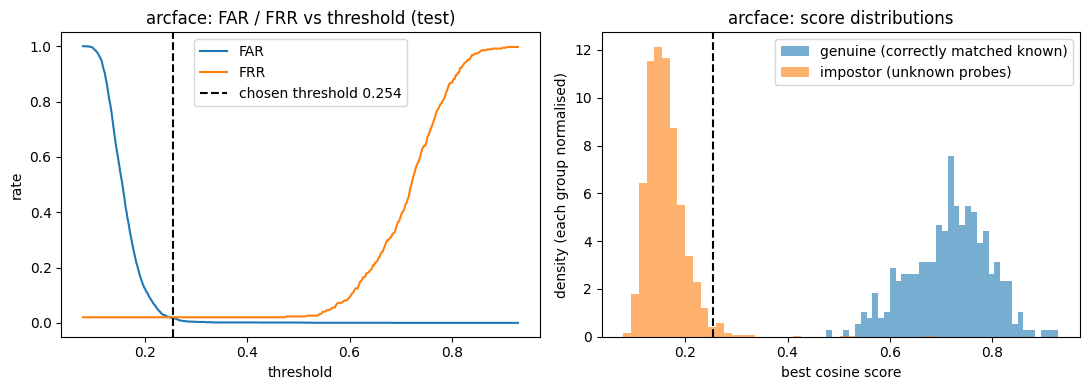

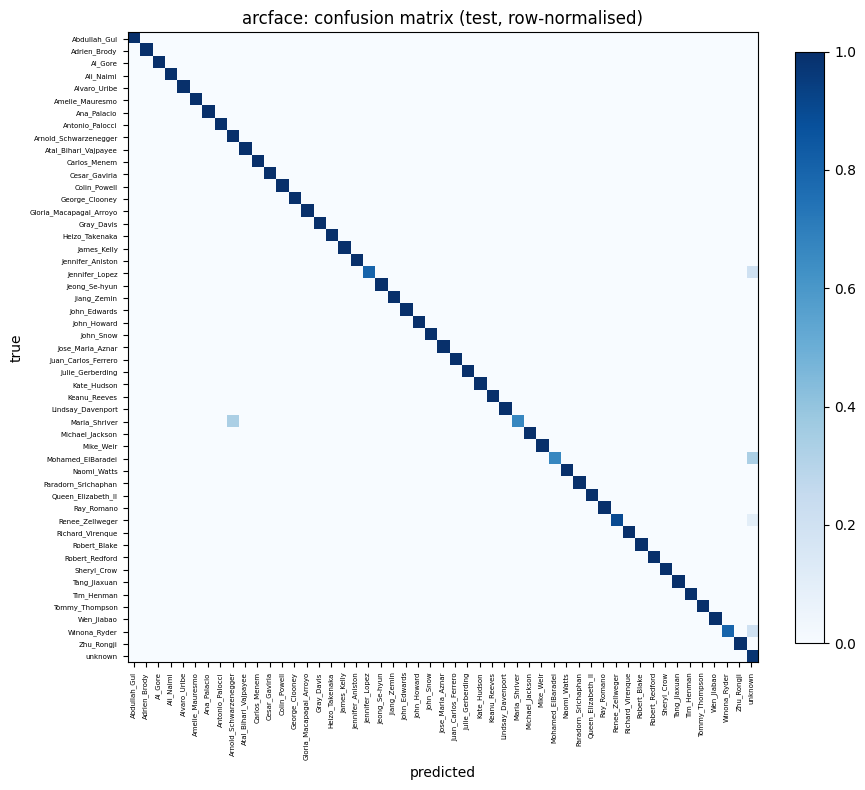

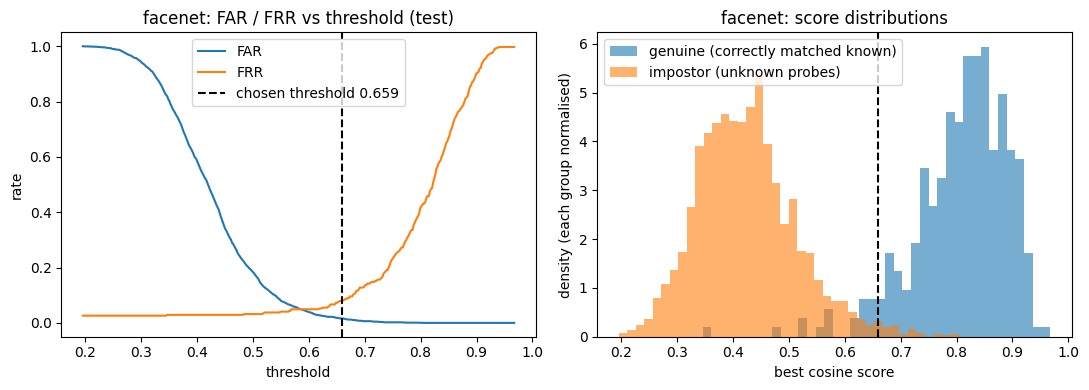

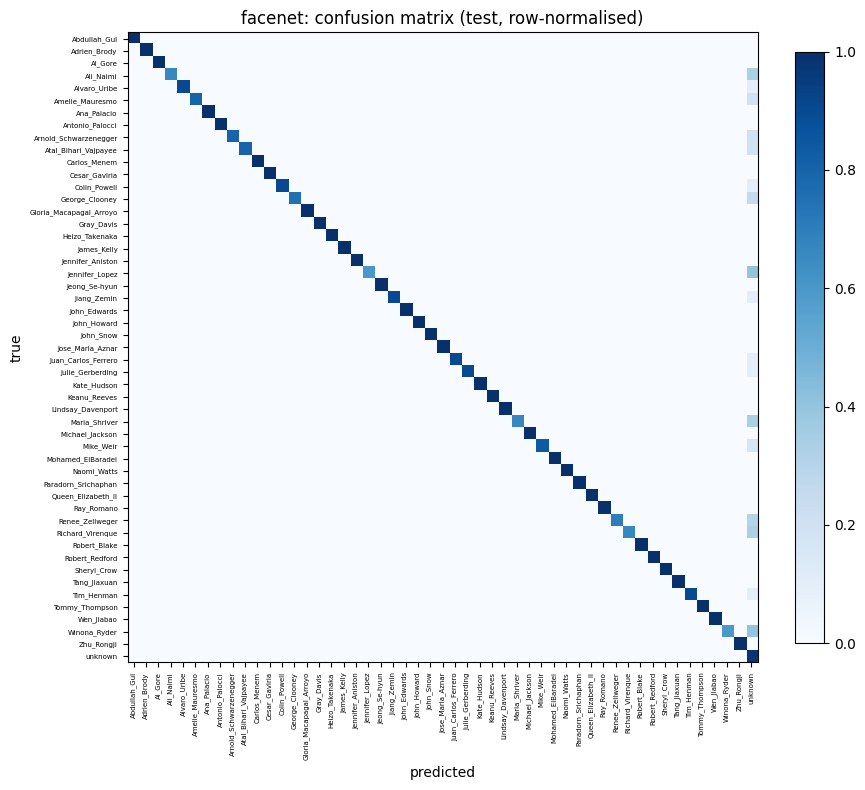

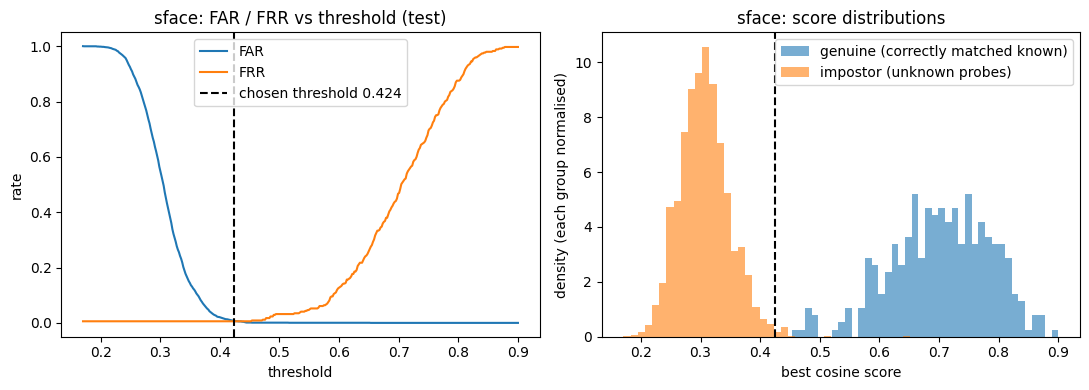

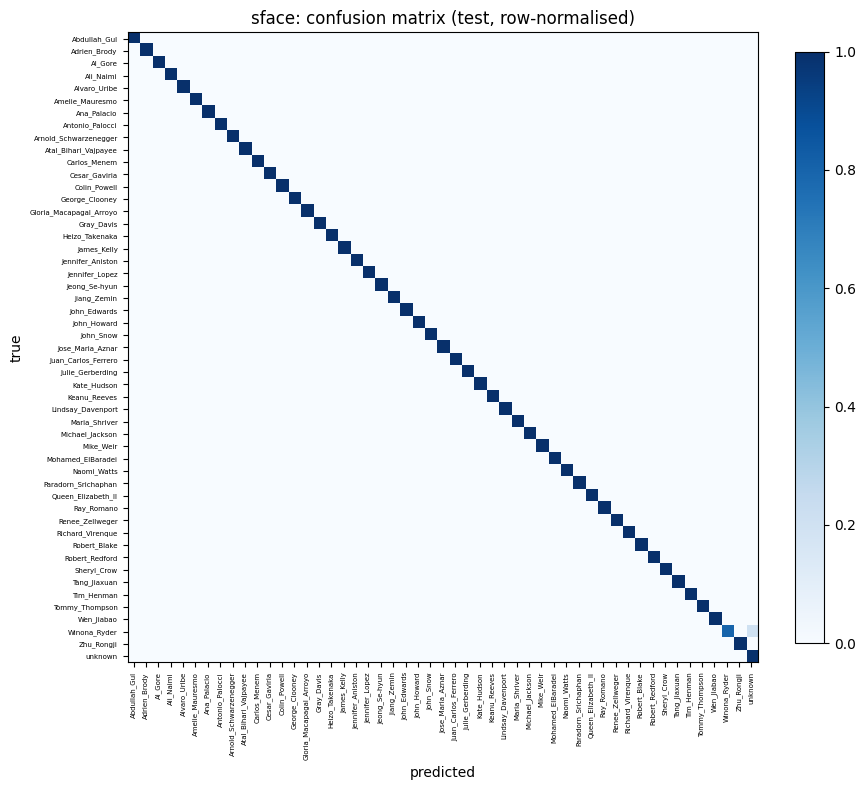

2026-09-20 15:18:12,891 INFO Saved 10 failure cases to results/failure_cases (false_accept: 5, false_reject: 4, misidentified: 1)


In [30]:
enrolled = sorted(split["gallery"])
for name, (kn, un) in scores.items():
    thr = results[name]["test"]["threshold"]
    kn_t, un_t = subset(kn, 1), subset(un, 1)
    plot_scores(name, thr, kn_t, un_t)
    plot_confusion(name, thr, kn_t, un_t, enrolled)
kn, un = scores["arcface"]
save_failure_cases("arcface", results["arcface"]["test"]["threshold"], subset(kn, 1), subset(un, 1))



In [31]:
  !ls -R results | head -40

results:
arcface_confusion.png
arcface_scores.png
cache
facenet_confusion.png
facenet_scores.png
failure_cases
metrics.json
sface_confusion.png
sface_scores.png

results/cache:
arcface.npz
facenet.npz
sface.npz

results/failure_cases:
arcface_00_false_accept.jpg
arcface_01_false_reject.jpg
arcface_02_misidentified.jpg
arcface_03_false_accept.jpg
arcface_04_false_reject.jpg
arcface_05_false_accept.jpg
arcface_06_false_reject.jpg
arcface_07_false_accept.jpg
arcface_08_false_reject.jpg
arcface_09_false_accept.jpg


In [32]:
!git config --global user.email "yogithajain73@gmail.com"
!git config --global user.name "yogitha-jain"

In [34]:
!ls *.py *.ipynb 2>/dev/null